# Exercise 1: Decision Tree Classifier (30 points)

In this exercise we will train a decision tree classifier for neutrino experiment data from [the MiniBOONE experiment](https://www.fnal.gov/pub/science/experiments/intensity/miniboone.html).

The goal is to prepare a binary classification to distinguish electron neutrinos (signal) from muon neutrinos (background). The dataset is taken from the UCI ML dataset repository.

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

data = fetch_openml("miniboone", parser="auto", version=1)
X, y = data["data"].values, (data["target"].values == "True").astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

## part 1(a): Data Exploration and Visualization (10 points)

Explore the dataset before building your ML classifier:
- How many events are in the training data and testing data?
- How many input features are there for each point in the training data?
- Plot at least three of the input features for events with `y_train==0` and for events with `y_train==1`.

(104051, 50)
(26013, 50)


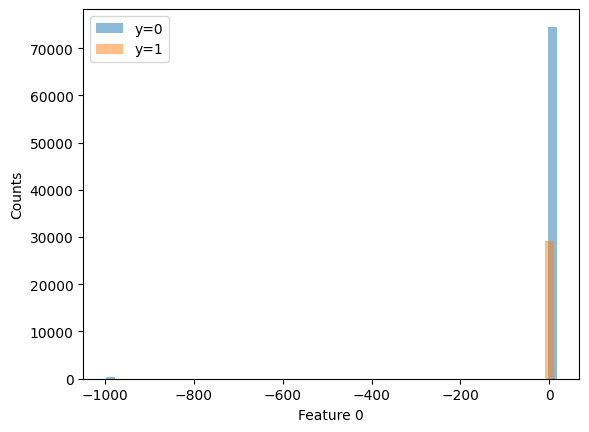

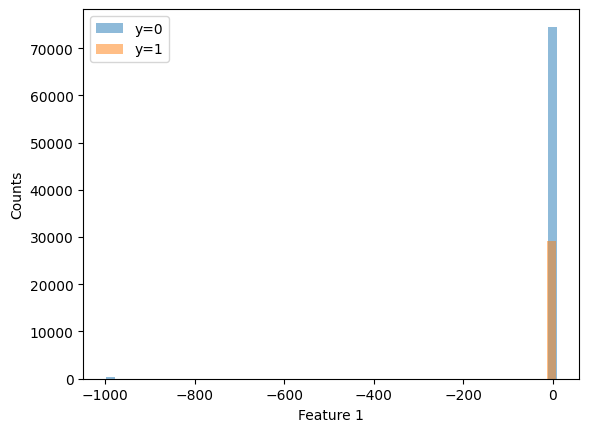

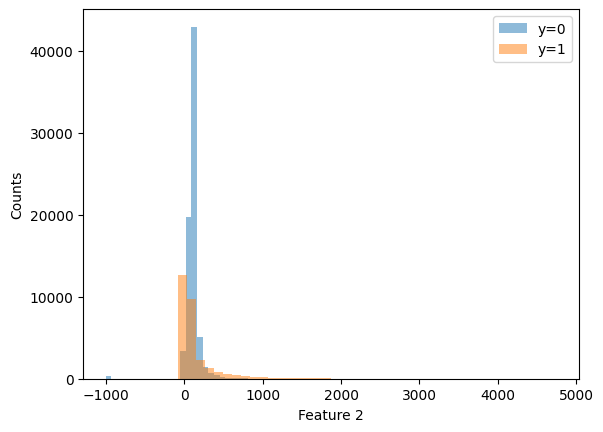

In [2]:
## to see the size of the data, im going to use .shape
print(X_train.shape)
print(X_test.shape)

## the first value in (x,y) is the size of events, so the training data has 104,051 events
## and the testing data has 26013 events. the second value is the amount of features per event
## so, they both have 50 features

import numpy as np
import matplotlib.pyplot as plt

X_one = X_train[y_train == 1]
X_zero = X_train[y_train == 0]

features_to_plot = [0, 1, 2]  ## start with 0, 1, 2

## features 0 and 1 all have a lot of overlap on their plots, so they aren't super useful
## features since they dont distinguish well
## feature 2 seems to have more shape differences between y values, so this feature
## distinguishes them better

for feature in features_to_plot:
  plt.figure()
  plt.hist(X_zero[:, feature], bins=50, alpha=0.5, label="y=0")
  plt.hist(X_one[:, feature], bins=50, alpha=0.5, label="y=1")
  plt.legend()
  plt.xlabel(f"Feature {feature}")
  plt.ylabel("Counts")
  plt.show()

## part 1(b): Decision Tree (10 points)

Train a simple `DecisionTreeClassifier` with `max_depth=5` and the `gini` criterion to separate the electron neutrino signal and muon neutrino background.

Calculate the performance of the Decision Tree:
- confusion matrix
- ROC curve
- Area Under Curve (AUC)


Confusion Matrix:
[[17567  1091]
 [ 1738  5617]]
Area Under Curve (AUC): 0.9380973010266955


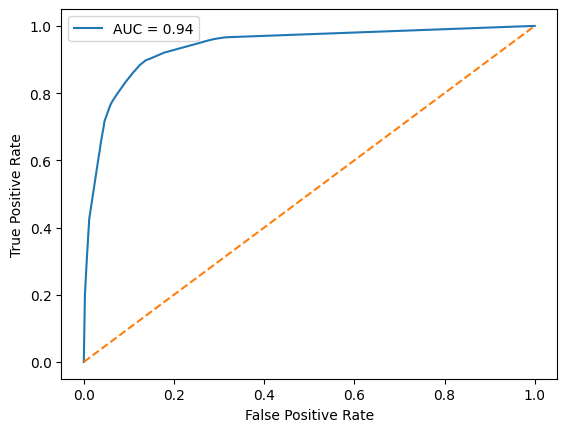

In [3]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc

## training for model
tree = DecisionTreeClassifier(max_depth=5, criterion="gini")
tree.fit(X_train, y_train)

## predict labels
y_pred = tree.predict(X_test)

## roc needs probability predictions
y_prob = tree.predict_proba(X_test)[:, 1]

## confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

## roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("Area Under Curve (AUC):", roc_auc)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(["AUC = %0.2f" % roc_auc])
plt.show()

this high auc value means that the model is very good at distinguishing the data. the random guessing line, which is 0.5, is much less than the roc curve, which means that the classifier is outperforming the random. the confusion matrix also shows that the model is correctly classifying the data more times than it is incorrectly doing it, since the true negative and positives are much greater than the false positives and negatives.

## part 1(c): Gini impurity measure

Visualize the decision tree, and pick three of the leaf nodes in your decision tree visualization.

For each node, calculate the Gini impurity by hand to check against the calculation from scikit-learn. Show the steps of your calculation and the result.

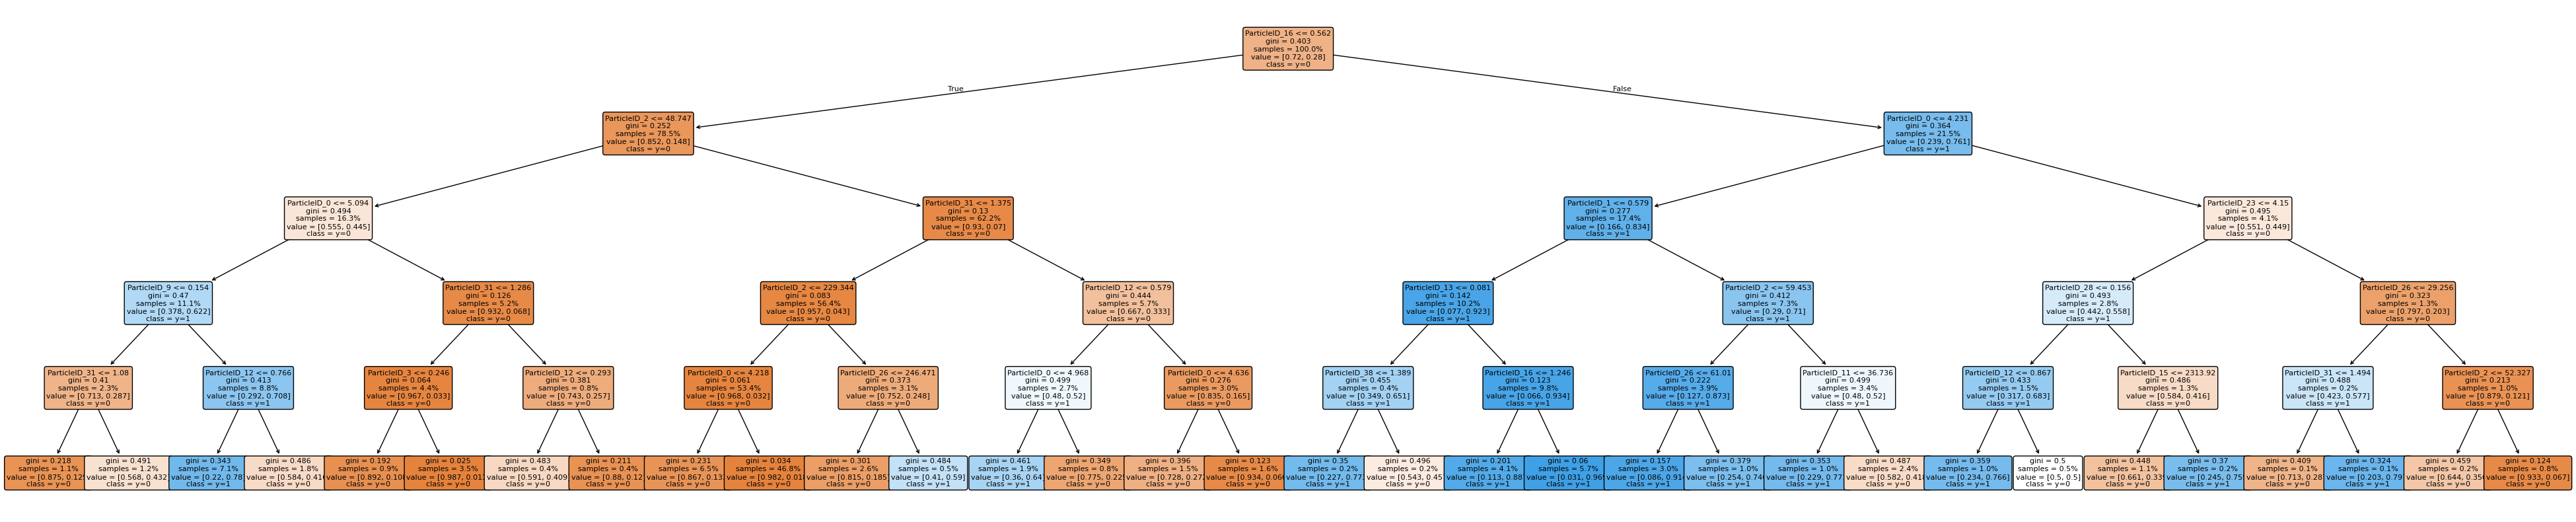

In [4]:
from sklearn.tree import plot_tree

## decision tree plot
plt.figure(figsize=(50, 10))
plot_tree(
    tree,
    max_depth=5,
    feature_names=data["feature_names"],
    class_names=["y=0", "y=1"],
    filled=True,
    fontsize=8,
    rounded=True,
    proportion=True,  ## showing the proportion instead of just counts because it
                      ## does some of the Gini calculation
    impurity=True,
)
plt.show()

In [5]:
## from the leaf nodes (bottom most boxes, final split)
## proportion gives p0 and p1, where p0 + p1 = 1
## and G = 1 - (p0^2 + p1^2)

## leaves picked (right-most three)
leaves = [
    {"name": "Leaf A", "gini_sklearn": 0.324, "value": [0.203, 0.797]},
    {"name": "Leaf B", "gini_sklearn": 0.459, "value": [0.644, 0.356]},
    {"name": "Leaf C", "gini_sklearn": 0.124, "value": [0.933, 0.067]},
]
## setup calc
def gini_from_proportions(p0, p1):
    return 1.0 - (p0**2 + p1**2)

for leaf in leaves:
    p0 = leaf["value"][0]
    p1 = leaf["value"][1]
    p0_squared = p0**2
    p1_squared = p1**2
    g_manual = gini_from_proportions(p0, p1)
    print(f"Hand done {leaf['name']}: {g_manual:.3f}")


Hand done Leaf A: 0.324
Hand done Leaf B: 0.459
Hand done Leaf C: 0.125


from the scikit calculation, the Gini impurity gave leaf A = 0.324, leaf B = 0.459, and lead C = 0.124. the hand done (not through the function) calculations gave almost the exact same values, just one rounding difference in leaf C

# Exercise 2: Backpropagation (30 points)

In this exercise you will gain some experience with the backpropagation equations and the numerical calculations of the gradient.



## part 2(a): Backpropagation theory (15 points)

Complete the proofs of [Nielsen's equations BP3 and BP4](http://neuralnetworksanddeeplearning.com/chap2.html#proof_of_the_four_fundamental_equations_(optional)).

In Nielsen's notation (but with layer numbers written in parenthesis for clarity):
$$
\begin{align}
\frac{\partial C}{\partial b_j^{(l)}} &= \delta_j^{(l)} & \quad \quad \text{(BP3)} \\
\frac{\partial C}{\partial w_{jk}^{(l)}} &= a_k^{(l-1)} \delta_j^{(l)} & \quad \quad \text{(BP4)}
\end{align}
$$
where $C$ is the cost function (loss function), $w$ and $b$ are weights and biases, $a$ is the post-activation output for the layer, and $\delta$ is the error of a single neuron.

work done on paper, then put into latex:

BP3:

since C depends on b only though z, apply chain rule:

$$
\frac{\partial C}{\partial b_j^{(l)}}
=
\frac{\partial C}{\partial z_j^{(l)}}
\frac{\partial z_j^{(l)}}{\partial b_j^{(l)}}
$$

from def of z:

$$
z_j^{(l)} = \sum_k w_{jk}^{(l)} a_k^{(l-1)} + b_j^{(l)}
$$
so we have:

$$
\frac{\partial z_j^{(l)}}{\partial b_j^{(l)}} = 1
$$
then,
$$
\frac{\partial C}{\partial b_j^{(l)}}
=
\frac{\partial C}{\partial z_j^{(l)}}
=
\delta_j^{(l)}
$$


BP4:

chain rule again:
$$
\frac{\partial C}{\partial w_{jk}^{(l)}}
=
\frac{\partial C}{\partial z_j^{(l)}}
\frac{\partial z_j^{(l)}}{\partial w_{jk}^{(l)}}
$$

when k' = k,

$$
\frac{\partial z_j^{(l)}}{\partial w_{jk}^{(l)}}
=
a_k^{(l-1)}
$$

sub in:
$$
\frac{\partial C}{\partial w_{jk}^{(l)}}
=
\delta_j^{(l)} a_k^{(l-1)}
$$


## part 2(b): Numerical calculation (15 points)

Consider a single perceptron node with 1-dimensional input $x$. The weight and bias of the node are $w=0.5$ and $b=0.1$. We use the ReLU activation function on the output of the node and the mean square error loss function.

If the data input and target are $x=1, y=1$:
- What is the loss function value?
- What is the gradient $\partial L/\partial w$?
- What is the gradient $\partial L/\partial b$?

You can do this by hand. Show your work, and feel free to check your answer with some code.




given values:

x = 1

y = 1

weight = 0.5

bias = 0.1

for pre-activation, we use z = wx + b and then activation function is $\hat{y}$ = $\mathrm{ReLU}(z)$

for the loss function, we can do $L = (\hat{y} - y)^2$

first find z:

 z = wx + b = (0.5)(1) + 0.1 = 0.6

apply ReLU:

z = 0.6 > 0, so $\hat{y}$ = ReLU(z) = 0.6

then, $L = (\hat{y} - y)^2$ = $(0.6 - 1)^2 = (-0.4)^2$ = 0.16

**** so, loss is 0.16

take deriv. of loss:

$L = (\hat{y} - y)^2$

$\frac{\partial L}{\partial \hat{y}} = 2(\hat{y} - y)$

plug in:

$\frac{\partial L}{\partial \hat{y}} = 2(0.6 - 1)$

$\frac{\partial L}{\partial \hat{y}} = -0.8$

then, for ReLU:

$\mathrm{ReLU}(z) =
\begin{cases}
z & \text{if } z > 0 \\
0 & \text{if } z \le 0
\end{cases}$

since z = 0.6 > 0,

$\frac{\partial \hat{y}}{\partial z} = 1$

z = wx + b ->
$\frac{\partial z}{\partial w} = x$

$\frac{\partial z}{\partial w} = 1$

$\frac{\partial z}{\partial b} = 1$

so,

***** $\frac{\partial L}{\partial w}
=
(-0.8)(1)(1) = -0.8 $

and

***** $\frac{\partial L}{\partial b}
=
(-0.8)(1)(1) = -0.8 $

In [6]:
## check with code:
import torch

x = torch.tensor(1.0)
y = torch.tensor(1.0)
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)

z = w * x + b
y_hat = torch.relu(z)
loss = (y_hat - y) ** 2

loss.backward()
print("Loss:", loss.item())
print("dL/dw:", w.grad.item())
print("dL/db:", b.grad.item())

Loss: 0.15999998152256012
dL/dw: -0.7999999523162842
dL/db: -0.7999999523162842


***** the code verifies the hand done work

# Exercise 3: Deep Neural Networks (40 points)

In this exercise we will train a deep neural network for neutrino experiment data from [the MiniBOONE experiment](https://www.fnal.gov/pub/science/experiments/intensity/miniboone.html).

The goal is similar to Exercise 1 above: prepare a binary classification to distinguish electron neutrinos (signal) from muon neutrinos (background).

In this exercise, you will set up a neural network model using PyTorch and train it using the MiniBOONE training data, then test it on the testing data.

## part 3(a) (20 points): DNN with tanh activation

Implement a deep neural network (at least 1 hidden layer between the input and output layers) to classify events as electron neutrinos (signal) or muon neutrinos (background). Use the tanh activation function, except in the output layer.

Here are some starting points for the DNN:
- 3 hidden layers w/ 64 units each
- BCE loss function
- SGD optimizer w/ batch size of 128

You should expect to train for at least 50 epochs.

In [7]:
from sklearn import model_selection
## start with all imports (some again just in case)
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score

## fetch data since it gave an error:
data = fetch_openml("miniboone", parser="auto", version=1)
X = data["data"].values
y = (data["target"].values == "True").astype(float)

## split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

## need to convert miniboone arrays to tensors + dataloaders
## convert to float32 tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## using training set statistics, standarize features (NN trains better)

mu = X_train.mean(dim=0, keepdim=True)  ## mean per feature
sigma = X_train.std(dim=0, keepdim=True)  ## std per feature
sigma[sigma == 0] = 1.0 ## avoid dividing by zero if a feature is constant

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

## data loaders
batch_size = 128
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

X_train.shape, y_train.shape



## define the DNN, 3 hidden layers and using tanh
class MiniBooNE_DNN(nn.Module):
  def __init__(self, input_dim, hidden_dim=64):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.Tanh(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.Tanh(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.Tanh(),
        nn.Linear(hidden_dim, 1),
    )

  def forward(self, x):
    return self.net(x)

model = MiniBooNE_DNN(input_dim=X_train.shape[1]).to(device)
model

## loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


## training loop
epochs = 50

for epoch in range(1, epochs + 1):
  model.train()     ## need model in training mode

  for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device)

    optimizer.zero_grad()     ## clear old gradients

    logits = model(xb)    ## forward pass
    loss = criterion(logits, yb)    ## compute BCE loss using logits
    loss.backward()    ## compute gradients
    optimizer.step()


    ## accumulate loss
    train_loss = loss.item() * xb.size(0)


  ## print occasionally so output isn't huge
  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch {epoch}/{epochs}")



Epoch 1/50
Epoch 10/50
Epoch 20/50
Epoch 30/50
Epoch 40/50
Epoch 50/50


## part 3(b) (10 points): DNN performance assessment

Calculate the performance of the DNN on the testing data:
- confusion matrix
- ROC curve
- Area Under Curve (AUC)



Confusion Matrix:
[[17432  1226]
 [ 1181  6174]]
AUC: 0.9624759936978605


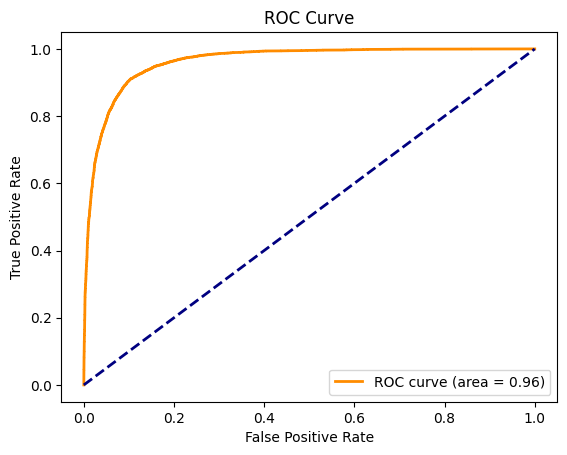

In [8]:
## evaluation
model.eval()

all_probs = []   ## store predicted probabilities
all_true = []   ## store true labels

## turn off gradient tracking
with torch.no_grad():
  for xb, yb in test_loader:
    xb = xb.to(device)
    logits = model(xb)      ## forward pass
    probs = torch.sigmoid(logits)   ## convert logits -> probs

    all_probs.append(probs.cpu())
    all_true.append(yb)

## combine batches into full arrays
all_probs = torch.cat(all_probs).numpy().ravel()
all_true = torch.cat(all_true).numpy().ravel()



## confusion matrix
## convert probs to class predictions
y_pred = (all_probs >= 0.5).astype(int)

cm = confusion_matrix(all_true, y_pred)
print("Confusion Matrix:")
print(cm)


## roc curve and auc
fpr, tpr, thresholds = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--") ## random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

the roc curve shows that the model is working very well since it is well curved and the auc is very close to 1

## part 3(c) (10 points): Change of activation function

Replace the sigmoid activation functions with the ReLU activation functions, in the layers where it is possible.
(Hint: there is one layer where you can't use the ReLU activation function--why not?)

What happens with the training and performance? Can you improve the performance relative to the original training with sigmoid activation functions?

[ReLU] Epoch 1/50 | Train Loss: 0.5918
[ReLU] Epoch 10/50 | Train Loss: 0.2584
[ReLU] Epoch 20/50 | Train Loss: 0.2358
[ReLU] Epoch 30/50 | Train Loss: 0.2220
[ReLU] Epoch 40/50 | Train Loss: 0.2112
[ReLU] Epoch 50/50 | Train Loss: 0.2014
Confusion Matrix:
 [[17568  1090]
 [ 1111  6244]]
AUC: 0.9685821439822128


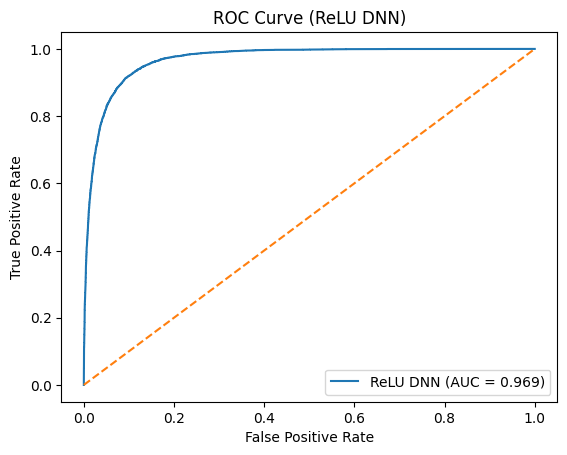

In [9]:
## same architecture, just changing the activation
class MiniBooNE_DNN_ReLU(nn.Module):
  def __init__(self, input_dim, hidden_dim=64):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1),
    )
  def forward(self, x):
    return self.net(x)

model_relu = MiniBooNE_DNN_ReLU(input_dim=X_train.shape[1]).to(device)
model_relu

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_relu.parameters(), lr=0.01)



## retrain the data but with this model
epochs = 50

for epoch in range(1, epochs + 1):
    model_relu.train()

    total_loss = 0.0
    total_examples = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model_relu(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_examples += xb.size(0)

    avg_loss = total_loss / total_examples

    if epoch == 1 or epoch % 10 == 0:
        print(f"[ReLU] Epoch {epoch}/{epochs} | Train Loss: {avg_loss:.4f}")


## assess performance again:
model_relu.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model_relu(xb)
        probs = torch.sigmoid(logits)   # logits -> probabilities
        all_probs.append(probs.cpu())
        all_true.append(yb)

all_probs = torch.cat(all_probs).numpy().ravel()
all_true  = torch.cat(all_true).numpy().ravel()

y_pred = (all_probs >= 0.5).astype(int)
cm = confusion_matrix(all_true, y_pred)

fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Confusion Matrix:\n", cm)
print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"ReLU DNN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ReLU DNN)")
plt.legend()
plt.show()


relu doesn't work in the output layer because the output must be a real- valued logit, which is positive or negative, but relu would restrict the output to >= 0, so we wouldn't have a strong class 0, so we can only use relu in hidden layers, or else the model will be less expressive.